<div style="background:#E9FFF6; color:#440404; padding:8px; border-radius: 4px; text-align: center; font-weight: 500;">IFN619 - Data Analytics for Strategic Decision Makers</div>

# IFN619 :: A2-DataAnalyticsCycle - tutorial exercises

## QUESTION

**Concern:** A key concern of many Queensland organisations and businesses is the impact of climate change on the coral and other marine life at the Great Barrier Reef. 
One indication of climate change is the rise in sea level. The [State of the Environment](https://www.stateoftheenvironment.des.qld.gov.au/climate/coasts-oceans/sea-level) report provides information on this indicator.

> **Question:** To what extent have changes in sea level been observed in the area of the Great Barrier Reef?

In this exercise, you will investigate history data on sea levels in two sites within the Great Barrier Reef. 

## DATA

Historic sea level data from within the Great Barrier Reef is available from [Queensland Government Open Data Portal](https://www.data.qld.gov.au/dataset/soe2020-sea-level/resource/2020-indicator-4-2-0-4)
1. Download the data as a CSV file, and save as `indicator-4-2-0-4.csv` in your `data` folder
2. Look at the contents of the file to understand the data. Note: the data instructions on the webpage provide some useful description of the data. 
3. Import the data as a `pandas` dataframe.

In [1]:
# Import libraries
import pandas as pd
import plotly.express as px

In [2]:
# Read a CSV into a dataframe
file_path = "data/"
file_name = "indicator-4-2-0-4.csv"
df = pd.read_csv(f"{file_path}{file_name}")
df

,Year,Month,Cape Ferguson,Rosslyn Bay,Global
0,1996,1,60.0,73,0.0
1,1996,2,115.0,145,-0.3
2,1996,3,132.0,89,3.7
3,1996,4,2.0,40,2.9
4,1996,5,26.0,56,4.8
...,...,...,...,...,...
285,2019,10,19.0,44,90.7
286,2019,11,13.0,18,90.8
287,2019,12,90.0,111,NaN
288,2020,1,127.0,125,NaN


## ANALYSIS

If we were to view all data including months we would be able to see the seasonality (as mentioned in the report). However, as we are just interested in the overall trend, we can get the mean change for the year. We can do this with the `groupby()` and `mean()` functions.

However, first we need to clean the data. Because 2020 is incomplete (doesn't have 12 months), it could skew any averages by reflecting only the seasonal variation for January and February. Therefore, we'll drop 2020 from the data BEFORE calculating the means. We can do this by *filtering* the dataframe to only include years before 2020.

In [3]:
# Remove incomplete 2020 data by selecting only years before 2020
clean_df = df[df['Year']<2020]
clean_df

,Year,Month,Cape Ferguson,Rosslyn Bay,Global
0,1996,1,60.0,73,0.0
1,1996,2,115.0,145,-0.3
2,1996,3,132.0,89,3.7
3,1996,4,2.0,40,2.9
4,1996,5,26.0,56,4.8
...,...,...,...,...,...
283,2019,8,35.0,49,92.2
284,2019,9,10.0,25,91.6
285,2019,10,19.0,44,90.7
286,2019,11,13.0,18,90.8


In [4]:
# Calculate the means for the year with groupby() and mean()
mean_cols = ['Cape Ferguson', 'Rosslyn Bay', 'Global']
mean_df = clean_df.groupby('Year')[mean_cols].mean()
mean_df

,Cape Ferguson,Rosslyn Bay,Global
Year,,,
1996,-11.083333,7.833333,4.400000
1997,-21.666667,-7.750000,8.950000
1998,52.250000,43.250000,14.466667
1999,53.166667,61.416667,14.583333
2000,51.916667,40.166667,17.908333
2001,26.500000,36.250000,22.491667
2002,4.416667,15.916667,25.975000
2003,17.958333,34.750000,28.158333
2004,-8.833333,3.000000,30.216667


## VISUALISATION

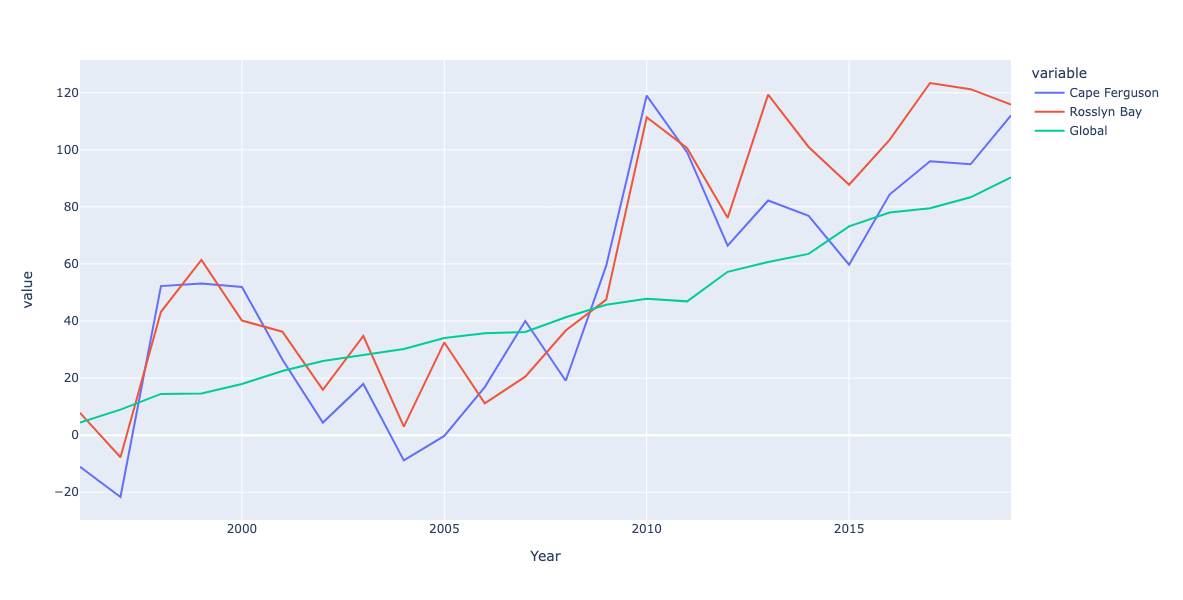

In [5]:
fig = px.line(mean_df, width = 800, height = 600)
fig.show()

## INSIGHTS

- What patterns did you find? 
- What is the recommendation for the concern?
- What other information would be helpful?
- What doesn't the data tell us?
- Can we make inferences?

[Write your insights here]